# Latent DenseAM / oscillator score model toy experiment in JAX

This notebook implements the two-dimensional latent DenseAM (DAM) toy from the note `latent_dam_force_matching.pdf`.

**Why $\sigma_t^2$ scaling matters.** Every energy model below is parameterised so that the **diffusion noise scale $\sigma_t^2$ appears explicitly** in both the visible Gaussian prior and the hidden-layer normalisation. Without this, the model force has magnitude at most $\mathcal O(1)$, but the Bayes-optimal denoising score at noise level $t$ has magnitude $\sim 1/\sigma_t^2$ — about $25$ at $\sigma_t^2 = 0.04$. A model that cannot produce a force of the right size near the modes collapses to a diffuse cloud at small $t$ even though it fits large-$t$ scores perfectly. With the $\sigma_t^2$ scaling baked in, the model score is $\mathcal O(1/\sigma_t^2)$ at every $t$ by construction and the latent models recover the modes cleanly.

The four models compared are
1. visible-only polynomial energy with a $\sigma_t^2$-scaled Gaussian prior;
2. binary hidden free-energy model in Gaussian–Bernoulli RBM form with a $\sigma_t^2$-scaled visible-hidden coupling;
3. categorical DenseAM with explicit $\sigma_t^2$ in the prototype log-sum-exp;
4. time-conditioned MLP score-network baseline.

All energy models are trained with denoising force matching at fixed time slices, with warm-start from the previous slice (the smooth driving protocol of the note, §8). The MLP is trained jointly over all diffusion times.

A numerical gradient check verifies that the analytic force expressions match autodiff of the log-density, and an empirical-score oracle sampler provides an upper bound on what the OU schedule can recover.

## Mathematical setup

**Forward noising.** Ornstein–Uhlenbeck SDE
$$dx = -x\,dt + \sqrt{2 k_BT}\,dw.$$
A finite-time corruption of a clean sample $x_0$ has closed form
$$x_t = a_t x_0 + \sigma_t \epsilon,\qquad a_t = e^{-t},\qquad \sigma_t^2 = k_BT(1 - e^{-2t}),\qquad \epsilon\sim\mathcal N(0,I).$$

**Denoising score target.** The conditional score of the Gaussian kernel is exact:
$$\nabla_{x_t}\log p(x_t \mid x_0) = -\frac{x_t - a_t x_0}{\sigma_t^2},$$
so the **denoising force target** is
$$f^{\star}(x_t, x_0, t) = k_BT\,\nabla_{x_t}\log p(x_t \mid x_0) = -\frac{k_BT}{\sigma_t^2}(x_t - a_t x_0).$$

**Model score.** For an energy / free-energy model $\mathcal F_\theta(x, t)$ we identify
$$\log p_\theta(x, t) \;=\; -\beta\,\mathcal F_\theta(x, t) + \text{const},\qquad \beta = (k_BT)^{-1},$$
so the model's physical force is
$$f_\theta(x, t) \;=\; -\nabla_x \mathcal F_\theta(x, t) \;=\; k_BT\,\nabla_x \log p_\theta(x, t).$$

**Denoising force-matching loss.** At each fixed diffusion time,
$$\mathcal L_t(\theta) \;=\; \tfrac12\,\mathbb E_{x_0, \epsilon} \big\| f_\theta(x_t, t) - f^{\star}(x_t, x_0, t) \big\|^2.$$

**Why $\sigma_t^2$ has to appear in the energy.** Let $\{\xi_\mu\}_{\mu=1}^{K}$ denote the training data points themselves — in the DenseAM picture these are the *memories* (or *prototype patterns*); in the diffusion picture they are the clean samples $x_0$ that the forward process noises. The empirical data distribution is a sum of point masses,
$$p_0(x) \;=\; \frac{1}{K}\sum_{\mu=1}^{K}\delta(x - \xi_\mu).$$
The forward OU process has the Gaussian transition kernel $p(x_t\mid x_0) = \mathcal N(x_t;\, a_t x_0,\, \sigma_t^2 I)$ derived above. Convolving that kernel against the empirical distribution gives the noise-marginal at time $t$ as a Gaussian mixture, with one component per training point, centred at the rescaled memories $a_t \xi_\mu$ and all sharing the same kernel width $\sigma_t$:
$$p_t(x) \;=\; \int p(x_t\mid x_0)\,p_0(x_0)\,dx_0 \;=\; \frac{1}{K}\sum_{\mu=1}^{K}\mathcal N(x;\, a_t \xi_\mu,\, \sigma_t^2 I).$$
Take the logarithm and expand the Gaussian quadratic $\lVert x - a_t \xi_\mu\rVert^2 = \lVert x\rVert^2 - 2 a_t\, x^\top \xi_\mu + a_t^2 \lVert \xi_\mu\rVert^2$. The $\lVert x\rVert^2/(2\sigma_t^2)$ piece is the *same for every memory* $\mu$, so it factors out of the sum:
$$\log p_t(x) \;=\; -\frac{1}{2\sigma_t^2}\lVert x\rVert^2 \;+\; \log\sum_\mu \exp\!\left[\frac{a_t\, x^\top \xi_\mu}{\sigma_t^2} - \frac{a_t^2\lVert \xi_\mu\rVert^2}{2\sigma_t^2}\right] \;+\; \text{const}.$$
This identity is exact for the noised empirical mixture. In the variance-exploding limit ($a_t \to 1$) it reduces to eq. (5) of [Pham et al., 2025](https://arxiv.org/abs/2505.21777) on the diffusion–DenseAM correspondence, with $\xi_\mu$ playing the role of stored DenseAM memories and $\sigma_t^2$ the role of the inverse DenseAM temperature $\beta^{-1}$.

Both the visible quadratic and the prototype log-sum-exp carry an explicit $1/\sigma_t^2$ prefactor, and the resulting score $\nabla_x \log p_t$ has magnitude $\sim 1/\sigma_t^2$ at small $t$. **Any parameterisation that does not let the visible quadratic scale this way cannot represent $\log p_t$ at small $t$.** All three energy models in this notebook carry the $1/\sigma_t^2$ prefactor explicitly.

**Reverse-time sampler.** With $s = \tau - r$, the reverse-time OU SDE used at inference is
$$dx \;=\; \big[\,x + 2 f_\theta(x, s)\,\big]\, dr \;+\; \sqrt{2 k_BT}\, dw,$$
started from $x \sim \mathcal N(0, k_BT I)$.

In [1]:
# Core imports.
import math
import time
from functools import partial
from typing import Callable

import numpy as np
import jax
import jax.numpy as jnp
from jax import random
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", False)

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())


JAX version: 0.4.33
Devices: [CudaDevice(id=0)]


## Configuration

The defaults below run in a few minutes on a single GPU and are sufficient to demonstrate the qualitative result. `RESEARCH_MODE = True` increases data, time-slice density, and training steps for cleaner figures.


In [2]:
# ----------------------------------------------------------------------
# Experiment knobs.
# ----------------------------------------------------------------------
SEED = 0
DATASET = "mog8"      # one of: "mog8", "ring", "moons"
RESEARCH_MODE = False

if RESEARCH_MODE:
    N_TRAIN = 4096
    N_TIME = 24
    STEPS_PER_TIME = 600
    MLP_STEPS = 6000
    BATCH_SIZE = 512
    N_REVERSE_STEPS = 400
    N_SAMPLES = 2000
else:
    N_TRAIN = 1536
    N_TIME = 14
    STEPS_PER_TIME = 300
    MLP_STEPS = 6000
    BATCH_SIZE = 256
    N_REVERSE_STEPS = 300
    N_SAMPLES = 1000

# Physical/noising parameters.
kBT = 1.0
TAU = 2.5
T_MIN = 2e-2     # avoid the singular empirical score at exactly t=0
TIME_GRID = jnp.linspace(T_MIN, TAU, N_TIME)

# Model sizes.
N_BINARY_HIDDEN = 64
N_CATEGORICAL_PROTOTYPES = 64
MLP_WIDTH = 96
MLP_DEPTH = 3

# Optimisation.
LR_POLY = 3e-3
LR_BINARY = 5e-3
LR_CAT = 5e-3
LR_MLP = 2e-3
GRAD_CLIP = 5.0
REG_SCALE = 1e-6

# Visualisation.
GRID_LIM = 3.2
GRID_N = 120
SCORE_TEST_N = 512

key = random.PRNGKey(SEED)


2026-05-19 18:15:00.350194: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## Minimal PyTree Adam

Self-contained Adam over PyTrees of dictionaries/arrays; avoids an `optax` dependency.


In [3]:
def tree_zeros_like(tree):
    return jax.tree_util.tree_map(jnp.zeros_like, tree)


def tree_sqnorm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return jnp.array(0.0)
    return sum(jnp.sum(jnp.square(x)) for x in leaves)


def tree_l2norm(tree):
    return jnp.sqrt(tree_sqnorm(tree) + 1e-12)


def clip_tree(tree, max_norm):
    norm = tree_l2norm(tree)
    scale = jnp.minimum(1.0, max_norm / (norm + 1e-12))
    return jax.tree_util.tree_map(lambda x: x * scale, tree)


def adam_init(params):
    return {"m": tree_zeros_like(params), "v": tree_zeros_like(params),
            "t": jnp.array(0, dtype=jnp.int32)}


def adam_step(params, state, grads, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    t = state["t"] + 1
    m = jax.tree_util.tree_map(lambda m, g: beta1 * m + (1.0 - beta1) * g,
                                state["m"], grads)
    v = jax.tree_util.tree_map(lambda v, g: beta2 * v + (1.0 - beta2) * jnp.square(g),
                                state["v"], grads)
    m_hat = jax.tree_util.tree_map(lambda m: m / (1.0 - beta1 ** t), m)
    v_hat = jax.tree_util.tree_map(lambda v: v / (1.0 - beta2 ** t), v)
    params = jax.tree_util.tree_map(
        lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
        params, m_hat, v_hat)
    return params, {"m": m, "v": v, "t": t}


## Toy 2-D datasets

Three options are supported, selected via `DATASET` above.

- `mog8`: eight tight Gaussians on a circle of radius 2. Easiest dataset for discrete mode-coverage metrics and the cleanest demonstration of the $1/\sigma_t^2$ scaling fix, because the modes are well separated and very narrow.
- `ring`: a 1-d ring manifold in 2-d. Closest to the DenseAM/diffusion derivation in the note.
- `moons`: two interlocked moons. Tests non-convex manifold coverage.


Dataset: mog8 | train_data shape: (1536, 2)


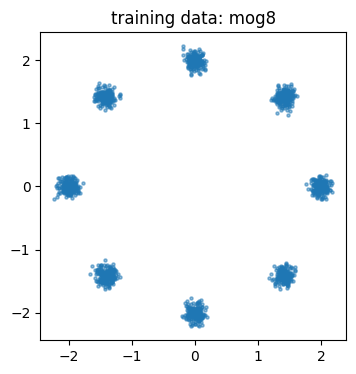

In [4]:
def make_mog8_centers(radius=2.0):
    angles = jnp.linspace(0.0, 2.0 * jnp.pi, 8, endpoint=False)
    return radius * jnp.stack([jnp.cos(angles), jnp.sin(angles)], axis=1)


def sample_mog8(key, n, radius=2.0, sigma=0.08):
    k_idx, k_eps = random.split(key)
    centers = make_mog8_centers(radius)
    idx = random.randint(k_idx, (n,), minval=0, maxval=centers.shape[0])
    x = centers[idx] + sigma * random.normal(k_eps, (n, 2))
    return x, {"kind": "mog8", "centers": centers, "sigma": sigma}


def sample_ring(key, n, radius=1.7, radial_sigma=0.045):
    k_theta, k_r = random.split(key)
    theta = random.uniform(k_theta, (n,), minval=0.0, maxval=2.0 * jnp.pi)
    r = radius + radial_sigma * random.normal(k_r, (n,))
    x = jnp.stack([r * jnp.cos(theta), r * jnp.sin(theta)], axis=1)
    return x, {"kind": "ring", "radius": radius, "n_bins": 36}


def moon_reference(n_per_moon=40):
    th = jnp.linspace(0.0, jnp.pi, n_per_moon)
    m1 = jnp.stack([jnp.cos(th), jnp.sin(th)], axis=1)
    m2 = jnp.stack([1.0 - jnp.cos(th), -jnp.sin(th) - 0.55], axis=1)
    ref = jnp.concatenate([m1, m2], axis=0)
    return 1.35 * (ref - jnp.mean(ref, axis=0, keepdims=True))


def sample_moons(key, n, noise=0.055):
    k_sel, k_theta, k_eps, k_perm = random.split(key, 4)
    is_second = random.bernoulli(k_sel, 0.5, (n,))
    th = random.uniform(k_theta, (n,), minval=0.0, maxval=jnp.pi)
    m1 = jnp.stack([jnp.cos(th), jnp.sin(th)], axis=1)
    m2 = jnp.stack([1.0 - jnp.cos(th), -jnp.sin(th) - 0.55], axis=1)
    x = jnp.where(is_second[:, None], m2, m1)
    x = 1.35 * (x - jnp.array([[0.5, 0.225]]))
    x = x + noise * random.normal(k_eps, (n, 2))
    x = x[random.permutation(k_perm, n)]
    return x, {"kind": "moons", "reference": moon_reference(50)}


def make_dataset(key, kind, n):
    if kind == "mog8":  return sample_mog8(key, n)
    if kind == "ring":  return sample_ring(key, n)
    if kind == "moons": return sample_moons(key, n)
    raise ValueError(kind)


key, sub = random.split(key)
train_data, data_meta = make_dataset(sub, DATASET, N_TRAIN)
print("Dataset:", data_meta["kind"], "| train_data shape:", train_data.shape)

plt.figure(figsize=(4.0, 4.0))
plt.scatter(np.asarray(train_data[:, 0]), np.asarray(train_data[:, 1]), s=5, alpha=0.5)
plt.gca().set_aspect("equal")
plt.title(f"training data: {DATASET}")
plt.show()


## OU corruption, denoising target, and the empirical-score oracle

`corrupt_ou` returns the noisy sample $x_t$ together with the denoising force target $f^{\star}(x_t, x_0, t) = -k_BT (x_t - a_t x_0)/\sigma_t^2$. `empirical_force` computes the exact Bayes-optimal force of the empirical OU-smoothed mixture (used only for evaluation and as an oracle sampler).


In [5]:
def ou_coeffs(t, kBT=1.0):
    """Return (a_t, sigma_t^2) for x_t = a_t x_0 + sigma_t epsilon."""
    a = jnp.exp(-t)
    sigma2 = kBT * (1.0 - a * a)
    sigma2 = jnp.maximum(sigma2, 1e-6)
    return a, sigma2


def corrupt_ou(key, x0, t, kBT=1.0):
    """Forward noising. Returns (xt, denoising_force_target)."""
    eps = random.normal(key, x0.shape)
    a, sigma2 = ou_coeffs(t, kBT)
    a_b = a if jnp.asarray(a).ndim == 0 else a[:, None]
    s2_b = sigma2 if jnp.asarray(sigma2).ndim == 0 else sigma2[:, None]
    xt = a_b * x0 + jnp.sqrt(s2_b) * eps
    target_force = -kBT * (xt - a_b * x0) / s2_b
    return xt, target_force


@partial(jax.jit, static_argnums=(3,))
def empirical_force(x, t, data, max_data=None, kBT=1.0):
    """k_BT * grad log p_t for the empirical OU-smoothed dataset (Bayes-optimal force)."""
    if max_data is not None:
        data = data[:max_data]
    a, sigma2 = ou_coeffs(t, kBT)
    diff = x[:, None, :] - a * data[None, :, :]
    logits = -jnp.sum(diff * diff, axis=-1) / (2.0 * sigma2)
    w = jax.nn.softmax(logits, axis=1)
    posterior_mean = jnp.sum(w[:, :, None] * (a * data[None, :, :]), axis=1)
    return kBT * (posterior_mean - x) / sigma2


@partial(jax.jit, static_argnums=(3,))
def empirical_log_p(x, t, data, max_data=None, kBT=1.0):
    """Empirical log p_t(x) up to an additive constant. Used for diagnostic plots."""
    if max_data is not None:
        data = data[:max_data]
    a, sigma2 = ou_coeffs(t, kBT)
    diff = x[:, None, :] - a * data[None, :, :]
    logits = -jnp.sum(diff * diff, axis=-1) / (2.0 * sigma2)
    return logsumexp(logits, axis=1)


## Model definitions

All three energy/free-energy models below define $\log p_\theta(x, t)$ up to an additive $x$-independent constant. Each is structured as

$$\log p_\theta(x, t) \;=\; -\frac{1}{2\sigma_t^2}\lVert x\rVert^2 \;+\; g_\theta(x, t),$$

so the **Gaussian-prior part of the score is automatically $-x/\sigma_t^2$** and grows correctly at small $t$. The model-specific term $g_\theta$ handles the data-attraction part and is also scaled with $\sigma_t^2$ where appropriate. The visible force is the gradient

$$f_\theta(x, t) \;=\; \nabla_x \log p_\theta(x, t).$$

In code we compute each model's force two ways:

- `*_force` uses `jax.grad` of `log_p` — short, hard to get wrong, easy to debug.
- `*_force_analytic` uses the closed-form gradient — fast in inference, and useful as a check that the energy you wrote is really the one whose score the analytic expression implements.

The numerical gradient check below confirms the two agree to floating-point precision.


### Model 1: visible-only polynomial energy

A pure-visible baseline. Beyond the $\sigma_t^2$-scaled Gaussian prior, the energy contains a small polynomial in $(x_1, x_2)$ with trainable coefficients:

$$g_\theta(x) \;=\; -\Big[\,\tfrac{\beta_{4,i}}{4} x_i^4 \;+\; \tfrac{\gamma_{6,i}}{6} x_i^6 \;+\; \tfrac{\kappa}{2}(x_1 - x_2)^2 \;+\; \tfrac{\lambda}{4}(x_1 - x_2)^4 \;+\; \chi_1 x_1 x_2^2 \;+\; \chi_2 x_1^2 x_2 \,\Big].$$

The $\gamma_6$ coefficient is kept positive via a softplus reparameterisation for coercivity. This is the smallest reasonable basis that can break circular symmetry (via $\chi$ and the asymmetric coupling); it cannot natively express eight separated modes.


In [6]:
def init_poly(key, data=None):
    k1, k2 = random.split(key)
    return {
        "beta4": 0.01 * random.normal(k1, (2,)),
        "g6_raw": -3.0 * jnp.ones((2,)),
        "kappa": jnp.array(0.0),
        "lam": jnp.array(0.0),
        "chi": 0.01 * random.normal(k2, (2,)),
    }


def poly_g(params, x):
    """Polynomial correction to the Gaussian prior. x is a single sample of shape (2,)."""
    g6 = jax.nn.softplus(params["g6_raw"]) + 1e-4
    x1, x2 = x[0], x[1]
    d = x1 - x2
    return (
        0.25 * jnp.sum(params["beta4"] * x ** 4)
        + (1.0 / 6.0) * jnp.sum(g6 * x ** 6)
        + 0.5 * params["kappa"] * d ** 2
        + 0.25 * params["lam"] * d ** 4
        + params["chi"][0] * x1 * x2 ** 2
        + params["chi"][1] * x1 ** 2 * x2
    )


def poly_log_p(params, x, sigma2):
    """log p_theta(x, t) up to constant, with x a single sample of shape (2,)."""
    return -0.5 * jnp.sum(x ** 2) / sigma2 - poly_g(params, x)


_poly_grad_single = jax.grad(poly_log_p, argnums=1)


def poly_force(params, x_batch, sigma2):
    return jax.vmap(lambda x: _poly_grad_single(params, x, sigma2))(x_batch)


### Model 2: binary hidden free energy (Gaussian–Bernoulli RBM)

A restricted hidden layer with $K$ binary units $h_a \in \{0, 1\}$, no hidden–hidden couplings, and a visible–hidden coupling matrix $W \in \mathbb R^{2 \times K}$. The joint energy at noise level $t$ is

$$E_\theta(x, h, t) \;=\; \frac{1}{2\sigma_t^2}\lVert x\rVert^2 \;-\; \frac{1}{\sigma_t^2}\sum_a h_a\,(b_a + W_a^\top x).$$

**The crucial choice is that the visible quadratic and the visible–hidden coupling share the same $1/\sigma_t^2$ prefactor.** This is equivalent to running the GBM at hidden inverse temperature $\beta_h(t) = 1/\sigma_t^2$: cold hidden layer at low diffusion noise (sharp modes), warm hidden layer at high diffusion noise (nearly Gaussian).

Adiabatic elimination of the hidden units gives the visible free energy

$$\mathcal F_\theta(x, t) \;=\; \frac{1}{2\sigma_t^2}\lVert x\rVert^2 \;-\; \frac{1}{\sigma_t^2}\sum_a \mathrm{softplus}(b_a + W_a^\top x),$$

and hence

$$\log p_\theta(x, t) \;=\; -\frac{1}{2\sigma_t^2}\lVert x\rVert^2 \;+\; \frac{1}{\sigma_t^2}\sum_a \mathrm{softplus}(b_a + W_a^\top x) \;+\; \text{const}.$$

The hidden equilibrium activation is $h_a^{\star} = \sigma(b_a + W_a^\top x)$. **The sigmoid argument is $\mathcal O(1)$ across all diffusion times**, so $W$ and $b$ stay at $\mathcal O(1)$ scale even at small $t$ — no exploding parameter regime to chase. The visible force is

$$f_\theta(x, t) \;=\; \frac{1}{\sigma_t^2}\!\left[\,-x \;+\; \sum_a h_a^{\star}\,W_a\,\right].$$

Trainable parameters per time slice: $W \in \mathbb R^{2 \times K}$, $b \in \mathbb R^K$.


In [7]:
def init_binary(key, data=None):
    kW, kb = random.split(key)
    return {
        "W": 0.3 * random.normal(kW, (2, N_BINARY_HIDDEN)),
        "b": 0.01 * random.normal(kb, (N_BINARY_HIDDEN,)),
    }


def binary_log_p(params, x, sigma2):
    """log p_theta(x, t) up to constant. x is a single sample of shape (2,)."""
    quad = -0.5 * jnp.sum(x ** 2) / sigma2
    logits = jnp.dot(x, params["W"]) + params["b"]
    hidden = jnp.sum(jax.nn.softplus(logits)) / sigma2
    return quad + hidden


def binary_hidden_eq(params, x_batch):
    """Equilibrium hidden activations h^* = sigmoid(b + W^T x). Shape (B, K)."""
    logits = x_batch @ params["W"] + params["b"]
    return jax.nn.sigmoid(logits)


def binary_force_analytic(params, x_batch, sigma2):
    """Analytic visible force: (1/sigma^2) * (-x + h^* @ W^T)."""
    h = binary_hidden_eq(params, x_batch)
    return (-x_batch + h @ params["W"].T) / sigma2


_binary_grad_single = jax.grad(binary_log_p, argnums=1)


def binary_force(params, x_batch, sigma2):
    """Force via autodiff of log_p. Used as the ground truth in the gradient check."""
    return jax.vmap(lambda x: _binary_grad_single(params, x, sigma2))(x_batch)


def binary_free_energy(params, x_batch, sigma2):
    """F = -log p up to constant; for diagnostic plotting."""
    return -jax.vmap(lambda x: binary_log_p(params, x, sigma2))(x_batch)


### Model 3: categorical DenseAM / prototype model

A categorical hidden variable $a \in \{1, \ldots, K\}$ with one prototype $c_a \in \mathbb R^2$ per state and a trainable bias $b_a$. The joint energy at noise level $t$ is

$$E_\theta(x, a, t) \;=\; \frac{1}{2\sigma_t^2}\lVert x - c_a\rVert^2 \;-\; b_a,$$

and marginalising the categorical hidden gives the DenseAM log-sum-exp free energy

$$\mathcal F_\theta(x, t) \;=\; -\log \sum_a \exp\!\left[-\frac{1}{2\sigma_t^2}\lVert x - c_a\rVert^2 + b_a\right],$$

so that

$$\log p_\theta(x, t) \;=\; \log \sum_a \exp\!\left[-\frac{1}{2\sigma_t^2}\lVert x - c_a\rVert^2 + b_a\right] \;+\; \text{const}.$$

This is the **natural Hopfield/DenseAM form of a Gaussian-mixture density at noise level $\sigma_t$** (cf. eq. (6) of the note). The hidden posterior is the softmax responsibility

$$r_a(x, t) \;=\; \mathrm{softmax}_a\!\left[-\frac{1}{2\sigma_t^2}\lVert x - c_a\rVert^2 + b_a\right],$$

and the visible force is

$$f_\theta(x, t) \;=\; \frac{1}{\sigma_t^2}\sum_a r_a\,(c_a - x).$$

**The explicit $1/\sigma_t^2$ in the force is essential.** Without it the model can only produce forces of magnitude $\lesssim \lVert c_{a^*} - x\rVert$, but the Bayes-optimal force at small $t$ has magnitude $\sim 1/\sigma_t^2 \approx 25$ at $\sigma_t^2 = 0.04$ — the model would be unable to sharpen the modes.

Trainable parameters per time slice: $c \in \mathbb R^{K \times 2}$, $b \in \mathbb R^K$.


In [8]:
def init_categorical(key, data, K=N_CATEGORICAL_PROTOTYPES):
    kidx, kjit = random.split(key)
    idx = random.randint(kidx, (K,), minval=0, maxval=data.shape[0])
    return {
        "c": data[idx] + 0.05 * random.normal(kjit, (K, 2)),
        "b": jnp.zeros((K,)),
    }


def categorical_log_p(params, x, sigma2):
    """log p_theta(x, t) up to constant. x is a single sample of shape (2,)."""
    c = params["c"]
    diffs = x[None, :] - c
    logits = -0.5 * jnp.sum(diffs ** 2, axis=-1) / sigma2 + params["b"]
    return logsumexp(logits)


def categorical_responsibilities(params, x_batch, sigma2):
    """r_a(x, t) = softmax over prototypes. Shape (B, K)."""
    c = params["c"]
    diffs = x_batch[:, None, :] - c[None, :, :]
    logits = -0.5 * jnp.sum(diffs ** 2, axis=-1) / sigma2 + params["b"][None, :]
    return jax.nn.softmax(logits, axis=-1)


def categorical_force_analytic(params, x_batch, sigma2):
    """Analytic visible force: (1/sigma^2) * sum_a r_a (c_a - x)."""
    r = categorical_responsibilities(params, x_batch, sigma2)
    return (r @ params["c"] - x_batch) / sigma2


_cat_grad_single = jax.grad(categorical_log_p, argnums=1)


def categorical_force(params, x_batch, sigma2):
    """Force via autodiff of log_p. Used as the ground truth in the gradient check."""
    return jax.vmap(lambda x: _cat_grad_single(params, x, sigma2))(x_batch)


def categorical_free_energy(params, x_batch, sigma2):
    """F = -log p up to constant."""
    return -jax.vmap(lambda x: categorical_log_p(params, x, sigma2))(x_batch)


### Model 4: time-conditioned MLP score network

A black-box force network with no energy interpretation. Inputs are $(x_1, x_2, t/\tau, \sin(2\pi t/\tau), \cos(2\pi t/\tau))$; the output is the visible force directly. Trained jointly over all diffusion times. This is a capacity ceiling — it has no conservative-vector-field constraint and can in principle fit any force field — and also a sanity check on the OU schedule and the reverse sampler.


In [9]:
def glorot(key, fan_in, fan_out):
    lim = math.sqrt(6.0 / (fan_in + fan_out))
    return random.uniform(key, (fan_in, fan_out), minval=-lim, maxval=lim)


def init_mlp(key, width=MLP_WIDTH, depth=MLP_DEPTH):
    dims = [5] + [width] * depth + [2]
    keys = random.split(key, len(dims) - 1)
    layers = []
    for k, din, dout in zip(keys, dims[:-1], dims[1:]):
        layers.append({"W": glorot(k, din, dout), "b": jnp.zeros((dout,))})
    return {"layers": layers}


def time_features(t, batch_size):
    t = jnp.asarray(t)
    u = jnp.ones((batch_size, 1)) * (t / TAU) if t.ndim == 0 else (t[:, None] / TAU)
    return jnp.concatenate([u, jnp.sin(2.0 * jnp.pi * u), jnp.cos(2.0 * jnp.pi * u)], axis=-1)


def mlp_force(params, x, t):
    h = jnp.concatenate([x, time_features(t, x.shape[0])], axis=-1)
    for layer in params["layers"][:-1]:
        h = jnp.tanh(h @ layer["W"] + layer["b"])
    return h @ params["layers"][-1]["W"] + params["layers"][-1]["b"]


## Numerical gradient check

For the two latent models we compare the analytic force expression against `jax.grad` of `log_p`. They must agree to floating-point precision; if they don't, the analytic formula and the energy written in `log_p` are inconsistent and the analytic sampler will silently sample the wrong distribution.


In [10]:
key, sub = random.split(key)
x_test = random.normal(sub, (32, 2))

for sigma2_test in [0.05, 0.5, 2.0]:
    print(f"\nsigma_t^2 = {sigma2_test}")
    for name, init_fn, force_grad, force_analytic in [
        ("binary",       init_binary,       binary_force,      binary_force_analytic),
        ("categorical",  init_categorical,  categorical_force, categorical_force_analytic),
    ]:
        key, k_init = random.split(key)
        p = init_fn(k_init, train_data)
        f_grad = force_grad(p, x_test, sigma2_test)
        f_an   = force_analytic(p, x_test, sigma2_test)
        err = jnp.max(jnp.abs(f_grad - f_an))
        print(f"  {name:>12s}: max(|autograd - analytic|) = {float(err):.2e}")



sigma_t^2 = 0.05
        binary: max(|autograd - analytic|) = 9.54e-06
   categorical: max(|autograd - analytic|) = 5.72e-06

sigma_t^2 = 0.5
        binary: max(|autograd - analytic|) = 9.54e-07
   categorical: max(|autograd - analytic|) = 5.96e-07

sigma_t^2 = 2.0
        binary: max(|autograd - analytic|) = 1.79e-07
   categorical: max(|autograd - analytic|) = 1.19e-07


## Denoising force-matching training

**Energy models**: trained per-slice, high-noise to low-noise, with warm-start from the previous slice. This matches the smooth-driving protocol of §8 of the note. Now that the visible quadratic and the hidden coupling both carry the $1/\sigma_t^2$ prefactor, the trainable parameters stay at $\mathcal O(1)$ across all slices and warm-start works well.

**MLP**: trained jointly over uniformly sampled diffusion times in one optimisation. This is more sample-efficient but does not match the per-slice physical protocol.

The denoising target is $f^{\star} = -k_BT (x_t - a_t x_0)/\sigma_t^2$, computed from the known forward OU corruption.

### Why the autodiff gradient *is* the on-device update rule

In code the parameter update is just gradient descent with `jax.grad`:
```python
loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))
loss_val, grads = loss_and_grad(params, sub, data, t)
```
This is a software shortcut, not a different algorithm. The autodiff gradient $\partial L/\partial \theta$ for the squared loss $L = \tfrac12\lVert f_\theta - f^\star\rVert^2$ is **mathematically identical** to the explicit column-local update rules in §5 and §6 of the note (eq. 38 for binary, eq. 45 for categorical) — autodiff just doesn't expose the result in the structured form a crossbar peripheral would actually drive.

**Derivation for the categorical DAM.** The model force is $f_\theta(x_t, t) = \frac{1}{\sigma_t^2}\big(\sum_a r_a c_a - x_t\big)$ with responsibilities $r_a = \mathrm{softmax}_a\!\left[-\lVert x_t - c_a\rVert^2/(2\sigma_t^2) + b_a\right]$. Differentiating $L = \tfrac12\lVert f_\theta - f^\star\rVert^2$ by hand, with $\delta = f^\star - f_\theta$ the score error and $\bar c = \sum_b r_b c_b$ the responsibility-weighted mean prototype:

$$\frac{\partial L}{\partial c_a} \;=\; -\frac{\partial f_\theta}{\partial c_a}^{\!\top}\!\delta \;=\; -\frac{r_a}{\sigma_t^2}\Big[\,\delta \;+\; \frac{(c_a - \bar c)^\top \delta}{\sigma_t^2}\,(x_t - c_a)\,\Big],$$

so gradient descent gives the update

$$\boxed{\;\Delta c_a \;=\; -\eta\,\frac{\partial L}{\partial c_a} \;=\; \frac{\eta\, r_a}{\sigma_t^2}\Big[\,\underbrace{\delta}_{\text{Hebbian}} \;+\; \underbrace{\frac{(c_a - \bar c)^\top \delta}{\sigma_t^2}\,(x_t - c_a)}_{\text{column-aggregate susceptibility}}\,\Big].\;}$$

This is exactly the structure of eq. (45) of the note: a two-factor outer product $r_a\,\delta$ plus a four-factor "susceptibility" correction involving the column aggregate $(c_a - \bar c)^\top\delta$. There are two contributions because both $c_a$ *and* the responsibility $r_a$ depend on $c_a$ — the susceptibility term is the chain-rule piece from $r_a$.

**What each factor is in hardware.** Per crossbar element $(k, a)$ the update needs only:

| signal | broadcast | source |
|---|---|---|
| score error $\delta_k$ | along row $k$ | error voltage from peripherals |
| responsibility $r_a$ | along column $a$ | softmax / WTA output |
| column aggregate $(c_a - \bar c)^\top \delta / \sigma_t^2$ | along column $a$ | one extra crossbar read |
| visible − prototype $x_{t,k} - c_{a,k}$ | element-local | $x_{t,k}$ as row voltage, $c_{a,k}$ is the stored conductance |

So the autodiff gradient *can* be physically realised as coincident row/column pulses — that is precisely the note's "column-local" claim.

**Frozen-hidden simplification.** Dropping the susceptibility term leaves the pure Hebbian update $\Delta c_a \approx \eta\, r_a\, \delta / \sigma_t^2$ — eq. (40) of the note — a strict two-factor outer product, much cheaper in hardware (no column aggregate needed) but biased. Implementing this and comparing against the full autodiff gradient on the toy problem would quantify how much sample quality is lost in exchange for the simpler circuitry. This is a natural follow-up, in the same spirit as the §13.1 numerical gradient check already done above.

In [11]:
def make_per_slice_loss(force_fn, batch_size, reg_scale, kBT_val):
    def loss(params, key, data, t):
        k_idx, k_noise = random.split(key)
        idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        xt, target = corrupt_ou(k_noise, x0, t, kBT_val)
        sigma2 = ou_coeffs(t, kBT_val)[1]
        pred = force_fn(params, xt, sigma2)
        mse = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=-1))
        return mse + reg_scale * tree_sqnorm(params)
    return loss


def train_time_slices(name, init_fn, force_fn, key, data, t_grid,
                      steps_per_time, batch_size, lr,
                      reg_scale=REG_SCALE, grad_clip=GRAD_CLIP):
    key, k_init = random.split(key)
    params = init_fn(k_init, data)
    params_by_idx = [None for _ in range(len(t_grid))]
    losses_by_idx = [None for _ in range(len(t_grid))]
    loss_fn = make_per_slice_loss(force_fn, batch_size, reg_scale, kBT)
    loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))

    t0_wall = time.time()
    for idx in range(len(t_grid) - 1, -1, -1):
        opt_state = adam_init(params)
        t = t_grid[idx]
        per_step_losses = []
        last_loss = None
        for _ in range(steps_per_time):
            key, sub = random.split(key)
            loss_val, grads = loss_and_grad(params, sub, data, t)
            grads = clip_tree(grads, grad_clip)
            params, opt_state = adam_step(params, opt_state, grads, lr=lr)
            per_step_losses.append(loss_val)
            last_loss = loss_val
        params_by_idx[idx] = params
        losses_by_idx[idx] = np.asarray(jax.device_get(per_step_losses))
        s2 = float(ou_coeffs(t)[1])
        print(f"{name:>12s} | t={float(t):.3f} | sigma_t^2={s2:.4f} | loss={float(last_loss):.4e}")
    print(f"{name} finished in {time.time() - t0_wall:.1f}s")
    return params_by_idx, losses_by_idx, key


def make_mlp_loss(batch_size, reg_scale, kBT_val):
    def loss(params, key, data):
        k_idx, k_t, k_noise = random.split(key, 3)
        idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        t = random.uniform(k_t, (batch_size,), minval=T_MIN, maxval=TAU)
        xt, target = corrupt_ou(k_noise, x0, t, kBT_val)
        pred = mlp_force(params, xt, t)
        mse = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=-1))
        return mse + reg_scale * tree_sqnorm(params)
    return loss


def train_mlp_baseline(key, data, steps, batch_size, lr):
    key, k_init = random.split(key)
    params = init_mlp(k_init)
    opt_state = adam_init(params)
    loss_fn = make_mlp_loss(batch_size, REG_SCALE, kBT)
    loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))
    per_step_losses = []
    t0_wall = time.time()
    for step in range(steps):
        key, sub = random.split(key)
        loss_val, grads = loss_and_grad(params, sub, data)
        grads = clip_tree(grads, GRAD_CLIP)
        params, opt_state = adam_step(params, opt_state, grads, lr=lr)
        per_step_losses.append(loss_val)
        if step % max(1, steps // 10) == 0 or step == steps - 1:
            print(f"MLP | step={step:5d}/{steps} | loss={float(loss_val):.4e}")
    losses = np.asarray(jax.device_get(per_step_losses))
    print(f"MLP finished in {time.time() - t0_wall:.1f}s")
    return params, losses, key

In [12]:
trained = {}
loss_history = {}

key, sub = random.split(key)
trained["poly"], loss_history["poly"], key = train_time_slices(
    "poly", init_poly, poly_force, sub, train_data, TIME_GRID,
    STEPS_PER_TIME, BATCH_SIZE, LR_POLY)

key, sub = random.split(key)
trained["binary"], loss_history["binary"], key = train_time_slices(
    "binary", init_binary, binary_force_analytic, sub, train_data, TIME_GRID,
    STEPS_PER_TIME, BATCH_SIZE, LR_BINARY)

key, sub = random.split(key)
trained["categorical"], loss_history["categorical"], key = train_time_slices(
    "categorical", init_categorical, categorical_force_analytic, sub, train_data, TIME_GRID,
    STEPS_PER_TIME, BATCH_SIZE, LR_CAT)

key, sub = random.split(key)
trained["mlp"], loss_history["mlp"], key = train_mlp_baseline(sub, train_data, MLP_STEPS, BATCH_SIZE, LR_MLP)

        poly | t=2.500 | sigma_t^2=0.9933 | loss=1.4299e-01
        poly | t=2.309 | sigma_t^2=0.9901 | loss=2.1931e-01
        poly | t=2.118 | sigma_t^2=0.9855 | loss=1.0497e-01
        poly | t=1.928 | sigma_t^2=0.9788 | loss=6.3386e-02
        poly | t=1.737 | sigma_t^2=0.9690 | loss=7.6289e-02
        poly | t=1.546 | sigma_t^2=0.9546 | loss=1.0296e-01
        poly | t=1.355 | sigma_t^2=0.9335 | loss=1.4055e-01
        poly | t=1.165 | sigma_t^2=0.9026 | loss=2.1375e-01
        poly | t=0.974 | sigma_t^2=0.8574 | loss=3.0546e-01
        poly | t=0.783 | sigma_t^2=0.7912 | loss=5.1122e-01
        poly | t=0.592 | sigma_t^2=0.6941 | loss=8.2373e-01
        poly | t=0.402 | sigma_t^2=0.5521 | loss=1.6405e+00
        poly | t=0.211 | sigma_t^2=0.3440 | loss=4.2740e+00
        poly | t=0.020 | sigma_t^2=0.0392 | loss=5.3589e+02
poly finished in 27.9s
      binary | t=2.500 | sigma_t^2=0.9933 | loss=2.8447e-02
      binary | t=2.309 | sigma_t^2=0.9901 | loss=1.9985e-02
      binary | t=

## Convergence curves

Per-step training loss for each model. The denoising force-matching loss has a known **irreducible floor** set by the conditional variance of the target $f^\star$ given $x_t$:
$$L_{\min}(t) \;\approx\; \frac{a_t^2\, d\, \mathrm{Var}(x_0\mid x_t)}{2\,\sigma_t^4}.$$
For `mog8` at small $t$ the posterior $x_0\mid x_t$ collapses to the nearest mode (width $\sim\sigma_{\text{data}} = 0.08$), so $L_{\min}(t{=}0.02) \approx 4$. A curve that has flattened *at* that floor is fully trained; a curve still descending or sitting well above it is under-trained or architecturally limited.

For the energy models each line is one time slice, coloured from dark (high noise, easy) to light (low noise, hard). The MLP panel shows the joint-time loss with a 50-step moving average overlay.

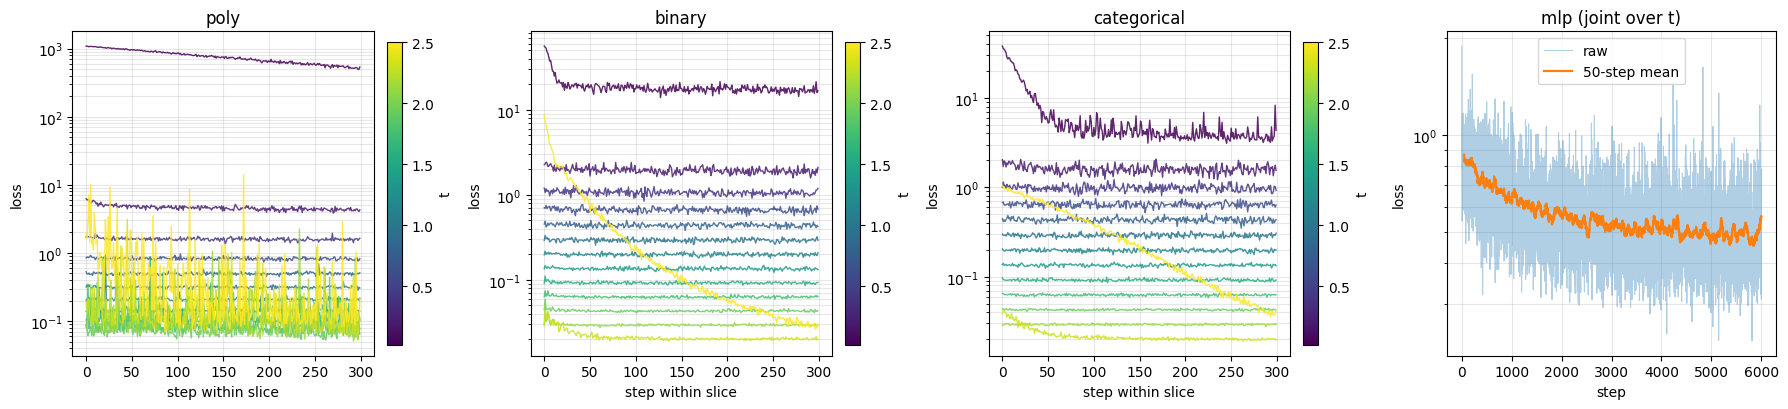

\nFinal loss per time slice vs Bayes-optimal floor (mog8, sigma_data=0.08)
       t    sigma_t^2      L_min       poly     binary     categ.
   0.020       0.0392   4.00e+00   5.36e+02   1.67e+01   4.32e+00
   0.211       0.3440   3.55e-02   4.27e+00   2.10e+00   1.55e+00
   0.402       0.5521   9.41e-03   1.64e+00   1.19e+00   9.28e-01
   0.592       0.6941   4.06e-03   8.24e-01   6.80e-01   6.35e-01
   0.783       0.7912   2.14e-03   5.11e-01   4.25e-01   4.35e-01
   0.974       0.8574   1.24e-03   3.05e-01   2.91e-01   3.08e-01
   1.165       0.9026   7.65e-04   2.14e-01   2.09e-01   2.00e-01
   1.355       0.9335   4.88e-04   1.41e-01   1.32e-01   1.33e-01
   1.546       0.9546   3.19e-04   1.03e-01   9.31e-02   9.19e-02
   1.737       0.9690   2.11e-04   7.63e-02   6.32e-02   6.30e-02
   1.928       0.9788   1.41e-04   6.34e-02   4.35e-02   4.28e-02
   2.118       0.9855   9.52e-05   1.05e-01   2.94e-02   2.93e-02
   2.309       0.9901   6.44e-05   2.19e-01   2.00e-02   1.96e-02
 

In [13]:
# Convergence curves for all models.
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
cmap = plt.cm.viridis

for ax, name in zip(axes[:3], ["poly", "binary", "categorical"]):
    if name not in loss_history:
        continue
    histories = loss_history[name]
    n_slices = len(histories)
    for idx, losses in enumerate(histories):
        if losses is None:
            continue
        color = cmap(idx / max(1, n_slices - 1))
        ax.plot(losses, color=color, alpha=0.85, linewidth=1.0)
    ax.set_xlabel("step within slice")
    ax.set_ylabel("loss")
    ax.set_yscale("log")
    ax.set_title(name)
    ax.grid(alpha=0.3, which="both")
    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(vmin=float(TIME_GRID[0]),
                                                  vmax=float(TIME_GRID[-1])))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("t")

# MLP joint-time training curve
ax = axes[3]
if "mlp" in loss_history:
    losses = loss_history["mlp"]
    ax.plot(losses, alpha=0.35, color="C0", linewidth=0.8, label="raw")
    win = 50
    if len(losses) >= win:
        smoothed = np.convolve(losses, np.ones(win) / win, mode="valid")
        ax.plot(np.arange(win - 1, len(losses)), smoothed,
                color="C1", linewidth=1.6, label=f"{win}-step mean")
    ax.set_xlabel("step")
    ax.set_ylabel("loss")
    ax.set_yscale("log")
    ax.set_title("mlp (joint over t)")
    ax.legend()
    ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

# Compare the final per-slice loss against the Bayes-optimal floor for mog8.
if DATASET == "mog8":
    print(f"\\nFinal loss per time slice vs Bayes-optimal floor (mog8, sigma_data={data_meta['sigma']})")
    print(f"{'t':>8s} {'sigma_t^2':>12s} {'L_min':>10s} "
          f"{'poly':>10s} {'binary':>10s} {'categ.':>10s}")
    for idx, t in enumerate(TIME_GRID):
        a, s2 = ou_coeffs(t)
        a, s2 = float(a), float(s2)
        var_x0 = float(data_meta['sigma']) ** 2
        L_min = (a ** 2) * 2 * var_x0 / (2.0 * s2 ** 2)
        finals = {}
        for name in ["poly", "binary", "categorical"]:
            h = loss_history.get(name, [])
            finals[name] = float(h[idx][-1]) if (h and h[idx] is not None) else float("nan")
        print(f"{float(t):>8.3f} {s2:>12.4f} {L_min:>10.2e} "
              f"{finals['poly']:>10.2e} {finals['binary']:>10.2e} {finals['categorical']:>10.2e}")

## Reverse-time sampling

We integrate the reverse-time OU SDE

$$dx \;=\; [\,x + 2 f_\theta(x, s)\,]\,dr \;+\; \sqrt{2 k_BT}\,dw,\qquad s = \tau - r,$$

from $x \sim \mathcal N(0, k_BT I)$ at $r = 0$ down to $s = T_{\min}$ at $r = \tau$. For energy models we use the time-slice parameters nearest the current forward-time value $s$. For the binary and categorical latent models we provide two variants:

- **equilibrium hidden** (`reverse_sample_energy`): hidden variables are infinitely fast and always at $h^\star$ / $r^\star$.
- **finite hidden time scale** (`reverse_sample_*_finite_hidden`): hidden variables relax with a time constant $\tau_h$ relative to the visible time. `hidden_tau_ratio = 0` recovers the equilibrium sampler.


In [14]:
def nearest_time_idx(t, t_grid=TIME_GRID):
    return int(np.argmin(np.abs(np.asarray(t_grid) - float(t))))


def reverse_sample_energy(key, params_seq, force_fn, n_samples=N_SAMPLES,
                          n_steps=N_REVERSE_STEPS, clip_x=8.0):
    """Reverse OU sampler for per-slice energy models.

    force_fn(params, x_batch, sigma2) -> (B, 2).
    """
    key, k_init = random.split(key)
    x = jnp.sqrt(kBT) * random.normal(k_init, (n_samples, 2))
    dt = TAU / n_steps
    for step in range(n_steps):
        s = max(T_MIN, TAU - step * dt)
        params = params_seq[nearest_time_idx(s)]
        sigma2 = float(ou_coeffs(s)[1])
        f = force_fn(params, x, sigma2)
        key, k_noise = random.split(key)
        x = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT * dt) * random.normal(k_noise, x.shape)
        if clip_x is not None:
            x = jnp.clip(x, -clip_x, clip_x)
    return x, key


def reverse_sample_mlp(key, params, n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS, clip_x=8.0):
    key, k_init = random.split(key)
    x = jnp.sqrt(kBT) * random.normal(k_init, (n_samples, 2))
    dt = TAU / n_steps
    for step in range(n_steps):
        s = max(T_MIN, TAU - step * dt)
        f = mlp_force(params, x, jnp.ones((n_samples,)) * s)
        key, k_noise = random.split(key)
        x = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT * dt) * random.normal(k_noise, x.shape)
        if clip_x is not None:
            x = jnp.clip(x, -clip_x, clip_x)
    return x, key


def reverse_sample_binary_finite_hidden(
    key, params_seq, hidden_tau_ratio=0.05, n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS, clip_x=8.0
):
    key, k_init = random.split(key)
    x = jnp.sqrt(kBT) * random.normal(k_init, (n_samples, 2))
    dt = TAU / n_steps
    params = params_seq[nearest_time_idx(TAU)]
    h = binary_hidden_eq(params, x)
    for step in range(n_steps):
        s = max(T_MIN, TAU - step * dt)
        params = params_seq[nearest_time_idx(s)]
        sigma2 = float(ou_coeffs(s)[1])
        h_eq = binary_hidden_eq(params, x)
        if hidden_tau_ratio <= 0:
            h = h_eq
        else:
            alpha = 1.0 - math.exp(-dt / hidden_tau_ratio)
            h = h + alpha * (h_eq - h)
        f = (-x + h @ params["W"].T) / sigma2
        key, k_noise = random.split(key)
        x = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT * dt) * random.normal(k_noise, x.shape)
        if clip_x is not None:
            x = jnp.clip(x, -clip_x, clip_x)
    return x, key


def reverse_sample_cat_finite_hidden(
    key, params_seq, hidden_tau_ratio=0.05, n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS, clip_x=8.0
):
    key, k_init = random.split(key)
    x = jnp.sqrt(kBT) * random.normal(k_init, (n_samples, 2))
    dt = TAU / n_steps
    params = params_seq[nearest_time_idx(TAU)]
    sigma2_init = float(ou_coeffs(TAU)[1])
    r = categorical_responsibilities(params, x, sigma2_init)
    for step in range(n_steps):
        s = max(T_MIN, TAU - step * dt)
        params = params_seq[nearest_time_idx(s)]
        sigma2 = float(ou_coeffs(s)[1])
        r_eq = categorical_responsibilities(params, x, sigma2)
        if hidden_tau_ratio <= 0:
            r = r_eq
        else:
            alpha = 1.0 - math.exp(-dt / hidden_tau_ratio)
            r = r + alpha * (r_eq - r)
            r = r / jnp.sum(r, axis=-1, keepdims=True)
        f = (r @ params["c"] - x) / sigma2
        key, k_noise = random.split(key)
        x = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT * dt) * random.normal(k_noise, x.shape)
        if clip_x is not None:
            x = jnp.clip(x, -clip_x, clip_x)
    return x, key


In [15]:
samples = {}

key, sub = random.split(key)
samples["poly"], key = reverse_sample_energy(sub, trained["poly"], poly_force)

key, sub = random.split(key)
samples["binary_eq"], key = reverse_sample_energy(sub, trained["binary"], binary_force_analytic)

key, sub = random.split(key)
samples["categorical_eq"], key = reverse_sample_energy(sub, trained["categorical"], categorical_force_analytic)

key, sub = random.split(key)
samples["mlp"], key = reverse_sample_mlp(sub, trained["mlp"])

print({name: x.shape for name, x in samples.items()})


{'poly': (1000, 2), 'binary_eq': (1000, 2), 'categorical_eq': (1000, 2), 'mlp': (1000, 2)}


## Visual comparison of generated samples

The five panels show, left to right: training data, polynomial samples, binary-RBM samples (equilibrium hidden), categorical DenseAM samples (equilibrium hidden), MLP samples. With the $\sigma_t^2$ scaling baked into the energy, the latent models should place mass on the actual modes — the categorical model in particular should look qualitatively like the training data.


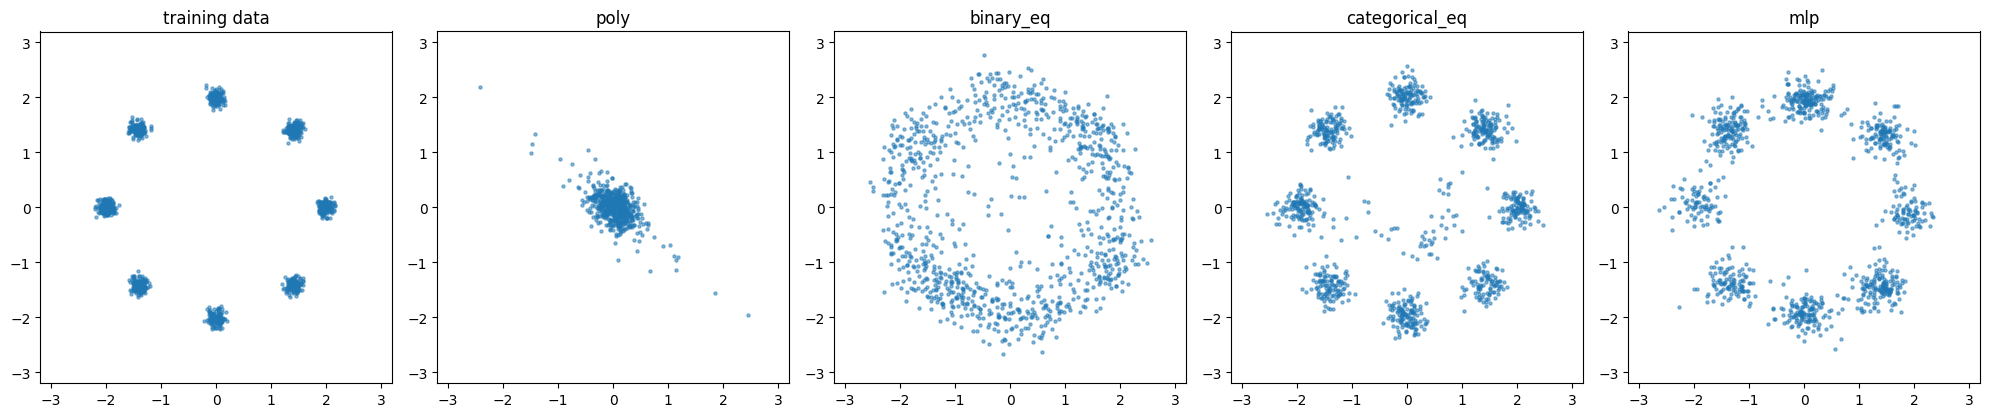

In [16]:
def plot_generated_samples(train_data, samples, max_points=1200):
    ncols = 1 + len(samples)
    fig, axes = plt.subplots(1, ncols, figsize=(4.0 * ncols, 4.0), squeeze=False)
    axes = axes[0]
    axes[0].scatter(np.asarray(train_data[:max_points, 0]), np.asarray(train_data[:max_points, 1]), s=5, alpha=0.5)
    axes[0].set_title("training data")
    axes[0].set_aspect("equal")
    for ax, (name, sx) in zip(axes[1:], samples.items()):
        arr = np.asarray(sx[:max_points])
        ax.scatter(arr[:, 0], arr[:, 1], s=5, alpha=0.5)
        ax.set_title(name)
        ax.set_aspect("equal")
    for ax in axes:
        ax.set_xlim(-GRID_LIM, GRID_LIM)
        ax.set_ylim(-GRID_LIM, GRID_LIM)
    plt.tight_layout()
    plt.show()


plot_generated_samples(train_data, samples)


## Coverage and score-error diagnostics

Coverage is dataset-specific: mode-coverage for `mog8`, angular-bin coverage for `ring`, reference-bin coverage for `moons`. Score error is the normalised RMSE of the model's force against the Bayes-optimal force of the empirical mixture, averaged over freshly sampled noisy points at several diffusion times.

If a model's energy lacks the $1/\sigma_t^2$ scaling, its score error is near-zero at large $t$ (where $\sigma_t^2 \to 1$ and a fixed $\tfrac12\lVert x\rVert^2$ prior happens to be right) and blows up at small $t$ (where the target force has magnitude $\sim 1/\sigma_t^2$). With the scaling in place, nRMSE should stay comparable across all $t$.


In [17]:
def coverage_metrics(samples_x, meta, min_frac=0.005):
    x = np.asarray(samples_x)
    n = x.shape[0]
    kind = meta["kind"]
    if kind == "mog8":
        centers = np.asarray(meta["centers"])
        d2 = ((x[:, None, :] - centers[None, :, :]) ** 2).sum(axis=-1)
        labels = d2.argmin(axis=1)
        counts = np.bincount(labels, minlength=centers.shape[0])
        threshold = max(2, int(min_frac * n))
        coverage = float(np.mean(counts >= threshold))
        probs = counts / max(1, counts.sum())
        uniform = np.ones_like(probs) / len(probs)
        kl = float(np.sum(np.where(probs > 0, probs * np.log(probs / uniform), 0.0)))
        mean_d = float(np.mean(np.sqrt(d2.min(axis=1))))
        return {"coverage": coverage, "kl_to_uniform": kl, "mean_nearest_dist": mean_d, "counts": counts}
    if kind == "ring":
        theta = np.mod(np.arctan2(x[:, 1], x[:, 0]), 2.0 * np.pi)
        bins = meta.get("n_bins", 36)
        labels = np.floor(theta / (2.0 * np.pi) * bins).astype(int)
        counts = np.bincount(labels, minlength=bins)
        threshold = max(2, int(min_frac * n))
        coverage = float(np.mean(counts >= threshold))
        r = np.sqrt((x ** 2).sum(axis=1))
        rmse = float(np.sqrt(np.mean((r - meta["radius"]) ** 2)))
        return {"coverage": coverage, "radial_rmse": rmse, "counts": counts}
    if kind == "moons":
        ref = np.asarray(meta["reference"])
        d2 = ((x[:, None, :] - ref[None, :, :]) ** 2).sum(axis=-1)
        labels = d2.argmin(axis=1)
        counts = np.bincount(labels, minlength=ref.shape[0])
        threshold = max(1, int(min_frac * n))
        coverage = float(np.mean(counts >= threshold))
        mean_d = float(np.mean(np.sqrt(d2.min(axis=1))))
        return {"coverage": coverage, "mean_ref_dist": mean_d, "counts": counts}
    raise ValueError(kind)


def model_force_at_t(model_name, t, x):
    sigma2 = float(ou_coeffs(t)[1])
    if model_name == "poly":
        return poly_force(trained["poly"][nearest_time_idx(t)], x, sigma2)
    if model_name == "binary":
        return binary_force_analytic(trained["binary"][nearest_time_idx(t)], x, sigma2)
    if model_name == "categorical":
        return categorical_force_analytic(trained["categorical"][nearest_time_idx(t)], x, sigma2)
    if model_name == "mlp":
        return mlp_force(trained["mlp"], x, jnp.ones((x.shape[0],)) * t)
    raise ValueError(model_name)


def score_error(model_name, key, data,
                t_values=(0.05, 0.15, 0.4, 1.0, 2.0), n=SCORE_TEST_N):
    out = []
    for t in t_values:
        if t < T_MIN or t > TAU:
            continue
        key, k_idx, k_noise = random.split(key, 3)
        idx = random.randint(k_idx, (n,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        xt, _ = corrupt_ou(k_noise, x0, t, kBT)
        f_exact = empirical_force(xt, t, data, min(2048, data.shape[0]), kBT)
        f_pred = model_force_at_t(model_name, t, xt)
        mse = jnp.mean(jnp.sum((f_pred - f_exact) ** 2, axis=-1))
        denom = jnp.mean(jnp.sum(f_exact ** 2, axis=-1)) + 1e-8
        out.append({"t": float(t), "nrmse": float(jnp.sqrt(mse / denom)), "mse": float(mse)})
    return out, key


for name, sx in samples.items():
    print("\n", name)
    for k, v in coverage_metrics(sx, data_meta).items():
        if k != "counts":
            print(f"  {k:>18s}: {v}")

for model_name in ["poly", "binary", "categorical", "mlp"]:
    if model_name in trained:
        key, sub = random.split(key)
        errs, key = score_error(model_name, sub, train_data)
        print("\nscore error", model_name)
        for row in errs:
            print(f"  t={row['t']:.3f} | nRMSE={row['nrmse']:.3f} | MSE={row['mse']:.3e}")



 poly
            coverage: 1.0
       kl_to_uniform: 0.31264735147200706
   mean_nearest_dist: 4.803673267364502

 binary_eq
            coverage: 1.0
       kl_to_uniform: 0.019330683526004425
   mean_nearest_dist: 0.521365225315094

 categorical_eq
            coverage: 1.0
       kl_to_uniform: 0.002347789922090451
   mean_nearest_dist: 0.2777867913246155

 mlp
            coverage: 1.0
       kl_to_uniform: 0.0297814020068302
   mean_nearest_dist: 0.2858983278274536



score error poly
  t=0.050 | nRMSE=4.395 | MSE=3.034e+02
  t=0.150 | nRMSE=2.124 | MSE=1.396e+01
  t=0.400 | nRMSE=0.829 | MSE=1.154e+00
  t=1.000 | nRMSE=0.153 | MSE=4.166e-02
  t=2.000 | nRMSE=0.174 | MSE=5.812e-02

score error binary
  t=0.050 | nRMSE=0.760 | MSE=8.910e+00
  t=0.150 | nRMSE=0.621 | MSE=1.375e+00
  t=0.400 | nRMSE=0.294 | MSE=1.455e-01
  t=1.000 | nRMSE=0.050 | MSE=4.268e-03
  t=2.000 | nRMSE=0.021 | MSE=9.125e-04

score error categorical
  t=0.050 | nRMSE=0.315 | MSE=1.558e+00
  t=0.150 | nRMSE=0.217 | MSE=1.902e-01
  t=0.400 | nRMSE=0.027 | MSE=1.240e-03
  t=1.000 | nRMSE=0.023 | MSE=9.302e-04
  t=2.000 | nRMSE=0.008 | MSE=1.251e-04

score error mlp
  t=0.050 | nRMSE=0.397 | MSE=2.541e+00
  t=0.150 | nRMSE=0.264 | MSE=2.633e-01
  t=0.400 | nRMSE=0.203 | MSE=6.333e-02
  t=1.000 | nRMSE=0.136 | MSE=3.162e-02
  t=2.000 | nRMSE=0.078 | MSE=1.119e-02


## Energy / free-energy landscapes and force fields

Per-panel: $-\log p_\theta(x, t)$ (or the model free energy) as a filled contour, the visible force as a quiver, training points overlaid. The right-most panel is the exact empirical OU-smoothed $-\log p_t$ as reference.

We plot at a small diffusion time so that the modes are visible. The categorical model's contours should track the eight-Gaussian structure of the empirical reference.


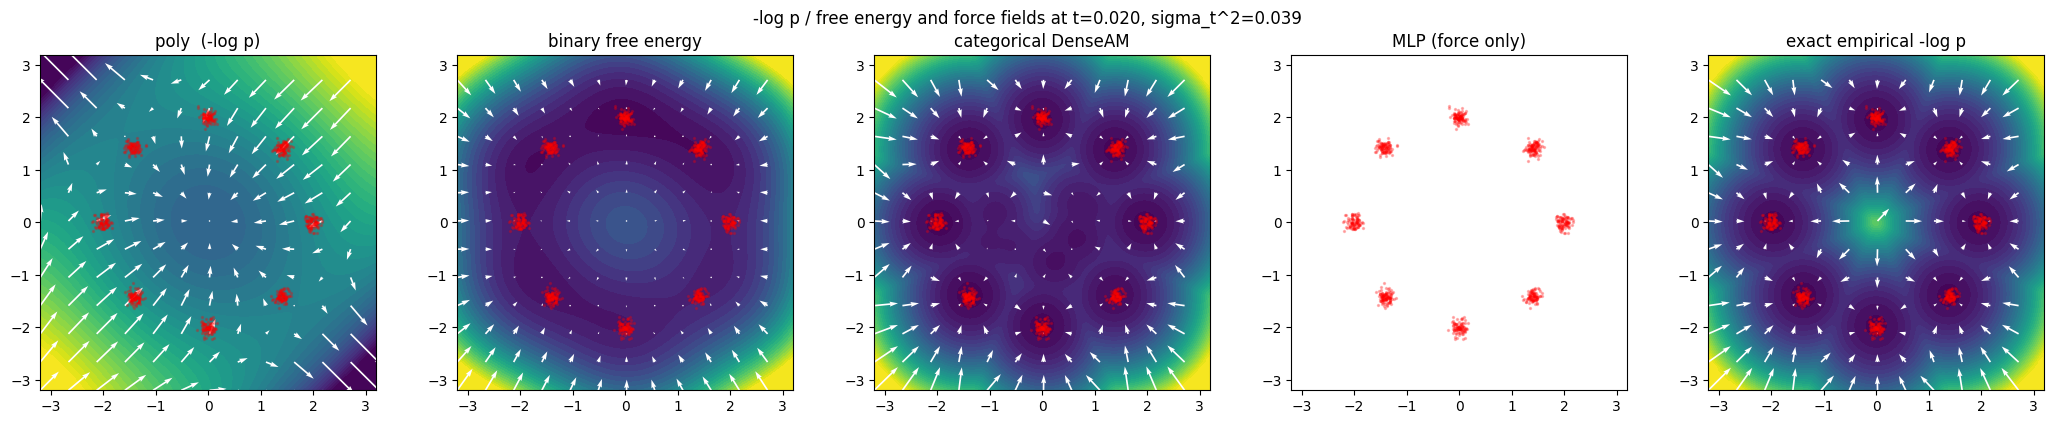

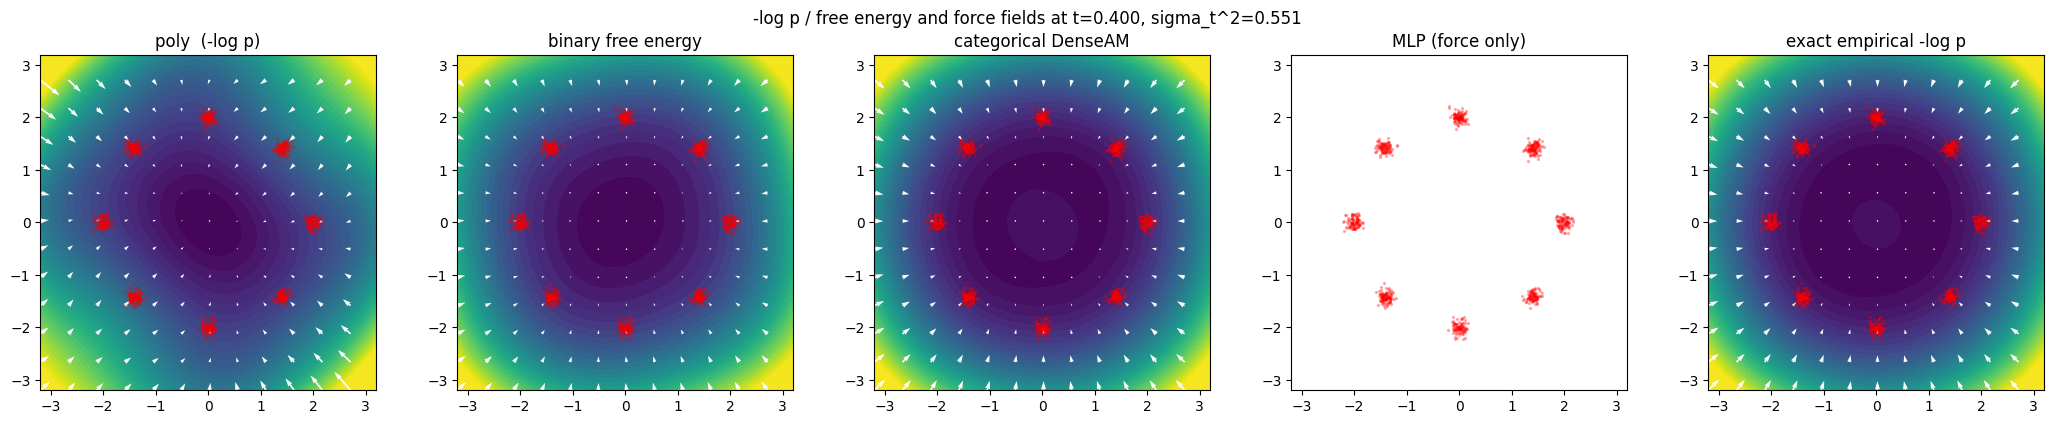

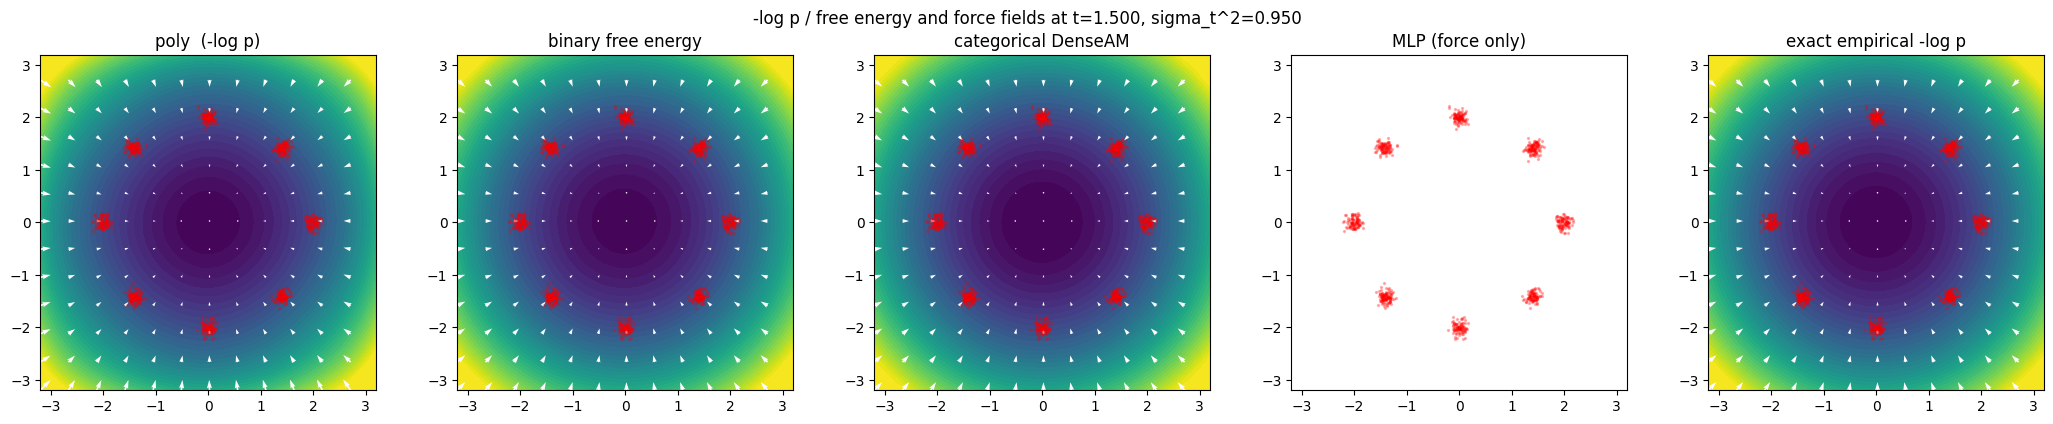

In [18]:
def make_grid(grid_lim=GRID_LIM, grid_n=GRID_N):
    xs = jnp.linspace(-grid_lim, grid_lim, grid_n)
    ys = jnp.linspace(-grid_lim, grid_lim, grid_n)
    X, Y = jnp.meshgrid(xs, ys)
    pts = jnp.stack([X.ravel(), Y.ravel()], axis=-1)
    return X, Y, pts


def plot_energy_and_force(t_plot=T_MIN, quiver_stride=10):
    X, Y, pts = make_grid()
    sigma2 = float(ou_coeffs(t_plot)[1])
    panels = []

    if "poly" in trained:
        p = trained["poly"][nearest_time_idx(t_plot)]
        E = -jax.vmap(lambda x: poly_log_p(p, x, sigma2))(pts)
        F = poly_force(p, pts, sigma2)
        panels.append(("poly  (-log p)", E, F))

    if "binary" in trained:
        p = trained["binary"][nearest_time_idx(t_plot)]
        E = binary_free_energy(p, pts, sigma2)
        F = binary_force_analytic(p, pts, sigma2)
        panels.append(("binary free energy", E, F))

    if "categorical" in trained:
        p = trained["categorical"][nearest_time_idx(t_plot)]
        E = categorical_free_energy(p, pts, sigma2)
        F = categorical_force_analytic(p, pts, sigma2)
        panels.append(("categorical DenseAM", E, F))

    if "mlp" in trained:
        panels.append((
            "MLP (force only)",
            None,
            mlp_force(trained["mlp"], pts, jnp.ones((pts.shape[0],)) * t_plot),
        ))

    panels.append((
        "exact empirical -log p",
        -empirical_log_p(pts, t_plot, train_data, min(2048, train_data.shape[0]), kBT),
        empirical_force(pts, t_plot, train_data, min(2048, train_data.shape[0]), kBT),
    ))

    fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4.1), squeeze=False)
    axes = axes[0]
    F_for_scale = panels[-1][2]
    scale = max(20.0, float(jnp.percentile(jnp.linalg.norm(F_for_scale, axis=-1), 90)) * 2.5)
    for ax, (title, energy, force) in zip(axes, panels):
        if energy is not None:
            Z = np.asarray(energy).reshape(X.shape)
            lo, hi = np.percentile(Z, [2, 98])
            ax.contourf(np.asarray(X), np.asarray(Y), np.clip(Z, lo, hi), levels=40)
        F = np.asarray(force).reshape(X.shape + (2,))
        sl = slice(None, None, quiver_stride)
        ax.quiver(np.asarray(X)[sl, sl], np.asarray(Y)[sl, sl],
                  F[sl, sl, 0], F[sl, sl, 1],
                  angles="xy", scale_units="xy", scale=scale, color="white")
        ax.scatter(np.asarray(train_data[:800, 0]), np.asarray(train_data[:800, 1]), s=2, alpha=0.25, color="red")
        ax.set_title(title)
        ax.set_aspect("equal")
        ax.set_xlim(-GRID_LIM, GRID_LIM)
        ax.set_ylim(-GRID_LIM, GRID_LIM)
    plt.suptitle(f"-log p / free energy and force fields at t={t_plot:.3f}, sigma_t^2={sigma2:.3f}")
    plt.tight_layout()
    plt.show()


plot_energy_and_force(T_MIN)
plot_energy_and_force(0.4)
plot_energy_and_force(1.5)


## Empirical-score oracle sampler

Reverse OU sampler driven by the **exact** Bayes-optimal score of the empirical training set, with no trainable model. This is the upper bound on what the OU schedule, reverse SDE, step size, and `T_MIN` can produce together. If the oracle does not recover the modes, no trained model on the same schedule will.


oracle metrics: {'coverage': 1.0, 'kl_to_uniform': 0.006137260731366648, 'mean_nearest_dist': 0.22979561984539032}


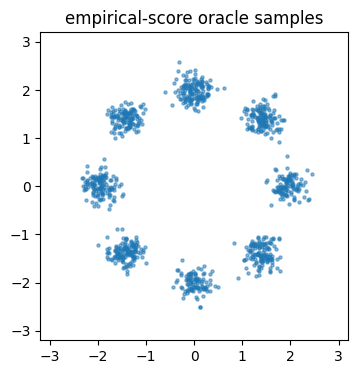

In [19]:
def reverse_sample_empirical_oracle(key, data, n_samples=N_SAMPLES, n_steps=N_REVERSE_STEPS,
                                     max_data=2048, clip_x=8.0):
    key, k_init = random.split(key)
    x = jnp.sqrt(kBT) * random.normal(k_init, (n_samples, 2))
    dt = TAU / n_steps
    for step in range(n_steps):
        s = max(T_MIN, TAU - step * dt)
        f = empirical_force(x, s, data, min(max_data, data.shape[0]), kBT)
        key, k_noise = random.split(key)
        x = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT * dt) * random.normal(k_noise, x.shape)
        if clip_x is not None:
            x = jnp.clip(x, -clip_x, clip_x)
    return x, key


key, sub = random.split(key)
oracle_samples, key = reverse_sample_empirical_oracle(sub, train_data,
                                                     n_samples=min(1000, N_SAMPLES))
print("oracle metrics:",
      {k: v for k, v in coverage_metrics(oracle_samples, data_meta).items() if k != "counts"})

plt.figure(figsize=(4.0, 4.0))
arr = np.asarray(oracle_samples)
plt.scatter(arr[:, 0], arr[:, 1], s=5, alpha=0.5)
plt.title("empirical-score oracle samples")
plt.gca().set_aspect("equal")
plt.xlim(-GRID_LIM, GRID_LIM)
plt.ylim(-GRID_LIM, GRID_LIM)
plt.show()


## Hidden time-scale sensitivity sweep

So far, the latent models have been sampled in the limit of infinitely fast hidden equilibration. In real hardware the hidden variables relax with some finite time constant $\tau_h$ relative to the visible time scale $\tau_x$. This sweep replaces the equilibrium hidden state by a first-order lag

$$h_{n+1} = h_n + \big(1 - e^{-\Delta t/\tau_{h,\text{ratio}}}\big)\,(h_n^\star - h_n),$$

where $\tau_{h,\text{ratio}} = \tau_h / \tau_x$. `ratio=0` recovers the equilibrium sampler; large ratios should degrade sample quality.

**Choice of metric.** Discrete mode coverage is essentially useless here: with $N$ samples and 8 modes, even a uniform scatter trivially assigns at least a few samples to every mode under the nearest-mode-centre argmin, so coverage saturates at 1.0 regardless of how dispersed the samples actually are. The signal lives in **mean nearest-mode distance** — for the `mog8` ground truth, samples within $\sim\!0.1$ of a mode centre are on-distribution; samples at distance $\sim\!1$ are off-distribution clouds *around* the modes. We plot mean nearest-mode distance below; coverage is still reported in the table for completeness.

       model  tau_ratio   coverage     mean_d         kl
      binary          0      1.000      0.519     0.0272
      binary       0.01      1.000      0.523     0.0164
      binary       0.05      1.000      0.594     0.0123
      binary        0.1      1.000      0.686     0.0106
      binary        0.5      1.000      1.131     0.0322
      binary          1      1.000      1.314     0.1112
 categorical          0      1.000      0.261     0.0042
 categorical       0.01      1.000      0.280     0.0054
 categorical       0.05      1.000      0.324     0.0154
 categorical        0.1      1.000      0.451     0.0077
 categorical        0.5      1.000      0.966     0.0120
 categorical          1      1.000      1.303     0.0126


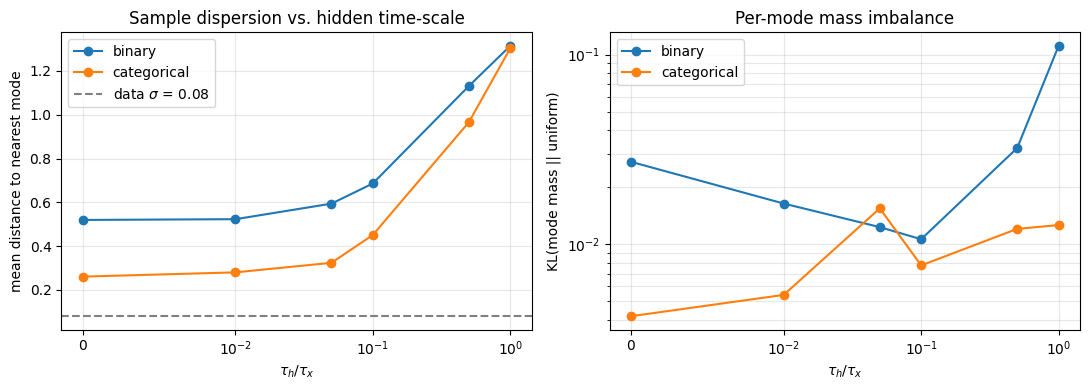

In [20]:
def hidden_timescale_sweep(key, ratios=(0.0, 0.01, 0.05, 0.1, 0.5, 1.0), n_samples=800):
    rows = []
    sweep_samples = {}
    if "binary" in trained:
        for r in ratios:
            key, sub = random.split(key)
            sx, key = reverse_sample_binary_finite_hidden(sub, trained["binary"],
                                                          hidden_tau_ratio=r, n_samples=n_samples)
            sweep_samples[f"binary_tau={r:g}"] = sx
            m = coverage_metrics(sx, data_meta)
            rows.append({"model": "binary", "tau_ratio": r,
                         **{k: v for k, v in m.items() if k != "counts"}})
    if "categorical" in trained:
        for r in ratios:
            key, sub = random.split(key)
            sx, key = reverse_sample_cat_finite_hidden(sub, trained["categorical"],
                                                       hidden_tau_ratio=r, n_samples=n_samples)
            sweep_samples[f"cat_tau={r:g}"] = sx
            m = coverage_metrics(sx, data_meta)
            rows.append({"model": "categorical", "tau_ratio": r,
                         **{k: v for k, v in m.items() if k != "counts"}})
    return rows, sweep_samples, key


key, sub = random.split(key)
time_rows, time_sweep_samples, key = hidden_timescale_sweep(sub)

# Print table including the metric that actually moves.
print(f"{'model':>12s} {'tau_ratio':>10s} {'coverage':>10s} {'mean_d':>10s} {'kl':>10s}")
for row in time_rows:
    print(f"{row['model']:>12s} {row['tau_ratio']:>10.3g} {row['coverage']:>10.3f} "
          f"{row.get('mean_nearest_dist', float('nan')):>10.3f} "
          f"{row.get('kl_to_uniform', float('nan')):>10.4f}")

# Plot the metric that actually moves: mean nearest-mode distance.
# Also overlay KL-to-uniform on a second axis to show within-mode mass redistribution.
if time_rows:
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))

    ax = axes[0]
    for model in sorted({r["model"] for r in time_rows}):
        rr = [r for r in time_rows if r["model"] == model]
        ax.plot([r["tau_ratio"] for r in rr],
                [r["mean_nearest_dist"] for r in rr],
                marker="o", label=model)
    ax.set_xscale("symlog", linthresh=0.01)
    ax.set_xlabel(r"$\tau_h / \tau_x$")
    ax.set_ylabel("mean distance to nearest mode")
    ax.set_title("Sample dispersion vs. hidden time-scale")
    ax.axhline(float(data_meta.get("sigma", 0.08)), color="grey", linestyle="--",
               label=f"data $\\sigma$ = {float(data_meta.get('sigma', 0.08)):.2f}")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    for model in sorted({r["model"] for r in time_rows}):
        rr = [r for r in time_rows if r["model"] == model]
        ax.plot([r["tau_ratio"] for r in rr],
                [r["kl_to_uniform"] for r in rr],
                marker="o", label=model)
    ax.set_xscale("symlog", linthresh=0.01)
    ax.set_yscale("log")
    ax.set_xlabel(r"$\tau_h / \tau_x$")
    ax.set_ylabel("KL(mode mass || uniform)")
    ax.set_title("Per-mode mass imbalance")
    ax.legend()
    ax.grid(alpha=0.3, which="both")

    plt.tight_layout()
    plt.show()

## Interpretation checklist

What this notebook lets you read off:

1. **Numerical gradient check.** Confirms each latent model's analytic force is the gradient of the energy actually written in `log_p`. If you ever change `log_p`, re-run this — it catches scaling bugs immediately.
2. **Empirical-score oracle.** Sanity-checks the OU schedule, reverse sampler, and `T_MIN`. If the oracle does not separate the modes, nothing trained on the same schedule will.
3. **Sample plots.** With the $\sigma_t^2$ scaling in place, the categorical DenseAM panel should look qualitatively like the training data (it is the natural form for the noised mixture). The binary panel should be similar; the polynomial baseline should clearly underperform; the MLP is the unconstrained capacity ceiling.
4. **Score-error table.** nRMSE should be small across all $t$. If a model is near-perfect at large $t$ (say $t \ge 1$) but catastrophic at small $t$ (say $t \le 0.15$), the visible quadratic in its energy is missing the $1/\sigma_t^2$ scaling.
5. **Hidden time-scale sweep.** This is the hardware-reality test: how fast must the latent layer be, relative to the visible dynamics, for the adiabatic-elimination story to hold? The note's claim depends on $\tau_h \ll \tau_x$; the sweep quantifies how much margin there is.

Together these are the diagnostics §13.1–§13.2 of the note suggests for the 2-D toy. The next step in the proposal's research path is §13.3, the same comparison on $12{\times}12$ MNIST 0/1 with $m \in \{16, 32, 64, 128, 256\}$.